# Segmentation des abonnés télécoms par regroupement k-means


## Résumé exécutif

Un opérateur télécom souhaite regrouper sa base d'abonnés postpayés en segments comportementaux afin de cibler des offres de rétention et de dimensionner correctement les forfaits data. Ce notebook génère un jeu de données synthétique d'utilisation des abonnés, puis exécute un pipeline complet de segmentation k-means en Base SAS : standardiser les variables d'utilisation avec **PROC STDIZE**, choisir le nombre de segments en comparant la statistique pseudo-F sur plusieurs valeurs candidates de k avec **PROC FASTCLUS**, ajuster un modèle final pondéré par FREQ qui score chaque abonné, puis exporter les centroïdes appris afin que l'instantané du mois prochain puisse être scoré sans re-segmentation. Le résultat est une segmentation réutilisable qui traduit la télémétrie brute d'utilisation en plan d'action de rétention.


## Sources de données

**Jeu de données synthétique : `WORK.SUBSCRIBERS`** (100 abonnés mobiles postpayés, générés directement avec `call streaminit(20260531)`)

| Variable | Type | Rôle | Description |
|----------|------|------|-------------|
| `cust_id` | Car | Identifiant | Identifiant de l'abonné (ex. `SUB000123`) |
| `tenure_months` | Num | Variable d'entrée continue | Nombre de mois d'activité de la ligne (1-72) |
| `data_gb` | Num | Variable d'entrée continue | Volume moyen mensuel de données mobiles utilisées, en Go |
| `voice_min` | Num | Variable d'entrée continue | Minutes vocales moyennes mensuelles |
| `intl_min` | Num | Variable d'entrée continue | Minutes internationales moyennes mensuelles |
| `support_calls` | Num | Variable d'entrée continue | Contacts avec le support client sur les 90 derniers jours |
| `monthly_charge` | Num | Variable d'entrée continue | Facture mensuelle actuelle, en dollars |
| `plan_tier` | Car | Profilage | Formule tarifaire : `Basique`, `Plus` ou `Illimité` |
| `n_lines` | Num | Pondération FREQ | Nombre de lignes sur le compte |

Trois profils comportementaux latents sont intégrés dans le générateur - *économe/valeur*, *gros consommateur de données/streaming*, et *forte sollicitation/à risque* - afin que le regroupement dispose d'une véritable structure à retrouver. Les variables continues alimentent le modèle k-means ; `plan_tier` est mise de côté pour un profilage a posteriori, et `n_lines` pondère chaque compte selon son nombre de lignes. Aucun fichier externe ni accès réseau n'est utilisé.


## La segmentation comportementale en cinq étapes

Les opérateurs mobiles gèrent des millions de lignes postpayées, et une stratégie de rétention uniforme gaspille de la marge sur des clients qui seraient restés de toute façon, tout en manquant ceux sur le point de partir. La **segmentation comportementale** transforme la télémétrie brute d'utilisation en quelques types de clients actionnables : les utilisateurs *économes/sensibles au prix*, les *gros consommateurs de données en streaming* qui sont de bonnes cibles de montée en gamme, et les comptes à *forte sollicitation/à risque* qui nécessitent une prise en charge proactive.

Ce notebook construit la segmentation avec `PROC FASTCLUS`, la procédure k-means (regroupement disjoint) de SAS. Nous allons :

1. Générer un jeu de données synthétique mais réaliste d'utilisation des abonnés.
2. Mettre les variables d'utilisation à une échelle commune avec **PROC STDIZE**.
3. **Choisir le nombre de segments** en comparant la statistique pseudo-F sur plusieurs valeurs candidates de k.
4. Ajuster un modèle final pondéré par FREQ qui **score** chaque abonné et profile les segments.
5. **Exporter les centroïdes appris** afin que le modèle puisse être réappliqué à l'instantané du mois prochain.


## Étape 1 - Générer une base d'abonnés synthétique

Nous simulons 100 abonnés postpayés. Chacun est tiré de l'un des trois profils latents avec des signatures d'utilisation différentes, de sorte qu'il existe une véritable structure de regroupement à retrouver. Nous fixons le flux avec `call streaminit` pour la reproductibilité, et nous bornons les valeurs simulées à des plages plausibles avec `max`/`min`/`round`.

La variable nominale `plan_tier` est corrélée au profil latent (les streamers penchent vers *Illimité* ; les utilisateurs économes vers *Basique*), et `n_lines` servira plus tard de pondération FREQ afin que les comptes familiaux multi-lignes comptent proportionnellement.


In [1]:
DONNÉES subscribers;
    APPELER streaminit(20260531);
    LONGUEUR cust_id $9 plan_tier $12;
    FAIRE i = 1 JUSQU_À 100;
        cust_id = cats('SUB', ÉCRIRE(i, z6.));

        /* Trois profils comportementaux latents, prévalence inégale */
        u = rand('uniform');
        SI u < 0.45 ALORS profile = 1;        /* économe / valeur           */
        SINON SI u < 0.80 ALORS profile = 2;   /* gros conso données/stream  */
        SINON profile = 3;                    /* forte sollicitation/risque */

        SI profile = 1 ALORS FAIRE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        FIN;
        SINON SI profile = 2 ALORS FAIRE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        FIN;
        SINON FAIRE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        FIN;

        /* Formule tarifaire corrélée au profil */
        p = rand('uniform');
        SI profile = 1 ALORS
            plan_tier = ifc(p < 0.70, 'Basique', ifc(p < 0.95, 'Plus', 'Illimité'));
        SINON SI profile = 2 ALORS
            plan_tier = ifc(p < 0.65, 'Illimité', ifc(p < 0.90, 'Plus', 'Basique'));
        SINON
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Illimité', 'Basique'));

        /* Lignes sur le compte : la plupart n'ont qu'une seule ligne */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Arrondir les valeurs monétaires / d'utilisation à une précision réaliste */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        SORTIE;
    FIN;
    SUPPRIMER i u p profile;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=subscribers(obs=10) noobs;
    ÉTIQUETTE cust_id="Identifiant abonné" tenure_months="Ancienneté (mois)" data_gb="Données (Go)"
          voice_min="Minutes voix" intl_min="Minutes internationales" support_calls="Appels support"
          monthly_charge="Facture mensuelle ($)" plan_tier="Formule tarifaire" n_lines="Nombre de lignes";
    TITRE "Échantillon d'enregistrements d'utilisation synthétiques des abonnés";
EXÉCUTER;


                          Échantillon d'enregistrements d'utilisation synthétiques des abonnés                          

 Identifiant abonné  Formule tarifaire   Ancienneté (mois)   Données (Go)  Minutes voix  Minutes internationales  Appels support  Facture mensuelle ($)  Nombre de lignes
SUB000001            Basique                            15            9.7           114                        5              11                  57.07                 2
SUB000002            Basique                            39            0.6           214                        2               1                  35.88                 3
SUB000003            Illimité                           45           23.9           325                        6               1                 103.94                 2
SUB000004            Basique                            41            1.9           202                        1               0                  61.69                 3
SUB000005            Basique


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Étape 2 - Mettre les variables à une échelle commune

Le k-means utilise la distance euclidienne, donc une variable de grande magnitude comme les minutes vocales dominerait une variable de faible magnitude comme les appels au support si nous regroupions sur les valeurs brutes. Le remède standard consiste à standardiser d'abord chaque variable continue pour obtenir une moyenne de 0 et un écart-type de 1. **PROC STDIZE** avec `METHOD=STD` fait exactement cela, en écrivant la copie centrée-réduite dans `WORK.SUBS_STD`. Nous conservons `cust_id`, `plan_tier` et `n_lines` sans modification afin qu'elles soient disponibles pour la pondération et le profilage ultérieurs.


In [2]:
PROCÉDURE stdize DONNÉES=subscribers out=subs_std METHOD=std;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=subs_std mean std maxdec=3;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ÉTIQUETTE tenure_months="Ancienneté (mois)" data_gb="Données (Go)" voice_min="Minutes voix"
          intl_min="Minutes internationales" support_calls="Appels support" monthly_charge="Facture mensuelle ($)";
    TITRE "Variables standardisées : moyenne ~ 0, écart-type ~ 1";
EXÉCUTER;


                          Échantillon d'enregistrements d'utilisation synthétiques des abonnés                          

                                 Variables standardisées : moyenne ~ 0, écart-type ~ 1                                  

                                                  The MEANS Procedure

 Variable        Label                             Mean     Std Dev
 ------------------------------------------------------------------
 tenure_months   Ancienneté (mois)                0.000       1.000
 data_gb         Données (Go)                    -0.000       1.000
 voice_min       Minutes voix                    -0.000       1.000
 intl_min        Minutes internationales          0.000       1.000
 support_calls   Appels support                  -0.000       1.000
 monthly_charge  Facture mensuelle ($)            0.000       1.000
 ------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 3 - Combien de segments ? Comparer le pseudo-F sur les valeurs candidates de k

Plutôt que de deviner le nombre de segments, nous ajustons FASTCLUS pour chaque k candidat et relevons les statistiques d'ajustement qu'il rapporte. La **statistique pseudo-F** (un rapport entre la variance inter-segments et la variance intra-segment) et le **R-carré global** récompensent tous deux la séparation ; un bon k est celui où le pseudo-F est élevé et où l'ajout d'un segment supplémentaire n'apporte plus que des gains marginaux. Une courte boucle macro exécute k = 2, 3, 4 avec `MAXITER=50` et `CONVERGE=0` (itérer jusqu'à la stabilité). Comparez les lignes `Pseudo F Statistic` et `Overall R-Squared` dans les trois listings ci-dessous : la structure intégrée comporte trois profils latents, et k = 3 donne la solution la plus solide et la plus équilibrée.


In [3]:
%macro pick_k;
    %FAIRE k = 2 %JUSQU_À 4;
        PROCÉDURE FASTCLUS DONNÉES=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            ÉTIQUETTE tenure_months="Ancienneté (mois)" data_gb="Données (Go)" voice_min="Minutes voix"
                  intl_min="Minutes internationales" support_calls="Appels support" monthly_charge="Facture mensuelle ($)";
            TITRE "Nombre de segments candidats : k = &k";
        EXÉCUTER;
    %FIN;
%mend pick_k;
%pick_k;


                                 Variables standardisées : moyenne ~ 0, écart-type ~ 1                                  


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Étape 4 - Ajuster la segmentation finale et scorer chaque abonné

Une fois k = 3 choisi, nous ajustons le modèle de production. Cette exécution est pleinement idiomatique pour une segmentation opérationnelle :

- L'instruction `FREQ` pondère chaque compte par `n_lines`, de sorte qu'un compte familial à quatre lignes contribue quatre fois plus qu'une ligne unique lors du calcul des centroïdes.
- `OUT=SCORED` écrit chaque abonné avec son `CLUSTER` attribué et sa `DISTANCE` au centroïde de ce segment ; l'instruction `ID` transporte `cust_id` dans cette table scorée.
- `MEAN=SEG_MEANS` capture les centroïdes par segment (à l'échelle standardisée).
- `OUTSEED=SEG_SEEDS` enregistre les centroïdes finaux au format de graine (seed) que FASTCLUS peut relire - c'est le modèle exporté que nous réappliquons à l'étape 6.

Les statistiques d'ajustement du modèle ont déjà été établies lors du balayage de l'étape 3, donc nous ajoutons ici l'option `SHORT` afin que le listing se concentre sur les tailles de segments et les centroïdes qui pilotent le score de sortie.


In [4]:
PROCÉDURE FASTCLUS DONNÉES=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    FRÉQUENCES n_lines;
    id cust_id;
    ÉTIQUETTE tenure_months="Ancienneté (mois)" data_gb="Données (Go)" voice_min="Minutes voix"
          intl_min="Minutes internationales" support_calls="Appels support" monthly_charge="Facture mensuelle ($)";
    TITRE "Segmentation finale : k = 3, pondérée par le nombre de lignes (FREQ)";
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=seg_means noobs;
    ÉTIQUETTE tenure_months="Ancienneté (mois)" data_gb="Données (Go)" voice_min="Minutes voix"
          intl_min="Minutes internationales" support_calls="Appels support" monthly_charge="Facture mensuelle ($)";
    TITRE "Centroïdes des segments (échelle standardisée)";
EXÉCUTER;


                                 Variables standardisées : moyenne ~ 0, écart-type ~ 1                                  


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Étape 5 - Profiler les segments en unités métier

La table scorée porte l'affectation `CLUSTER` de chaque abonné, mais à l'échelle standardisée les centroïdes sont difficiles à lire. Pour transformer les numéros de segments en personas métier, nous rejoignons l'affectation à la table `subscribers` d'origine et nous profilons en unités réelles - gigaoctets, minutes et dollars. PROC MEANS résume les variables continues par segment, et PROC FREQ croise la variable `plan_tier` mise de côté avec le segment pour montrer la répartition des formules de chaque persona.


                       Profils des segments : utilisation moyenne par segment (unités d'origine)                        

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Ancienneté (mois)

                                         N
                            CLUSTER    Obs      Mean      Std Dev      Minimum      Maximum
                            ---------------------------------------------------------------
                            1           51      33.2         14.7          1.0         61.0
                            2           31      40.5         14.0         17.0         67.0
                            3           18      12.7          7.1          1.0         30.0
                            ---------------------------------------------------------------

                                      Analysis Variable : data_gb Données (Go)

                                         N
  


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


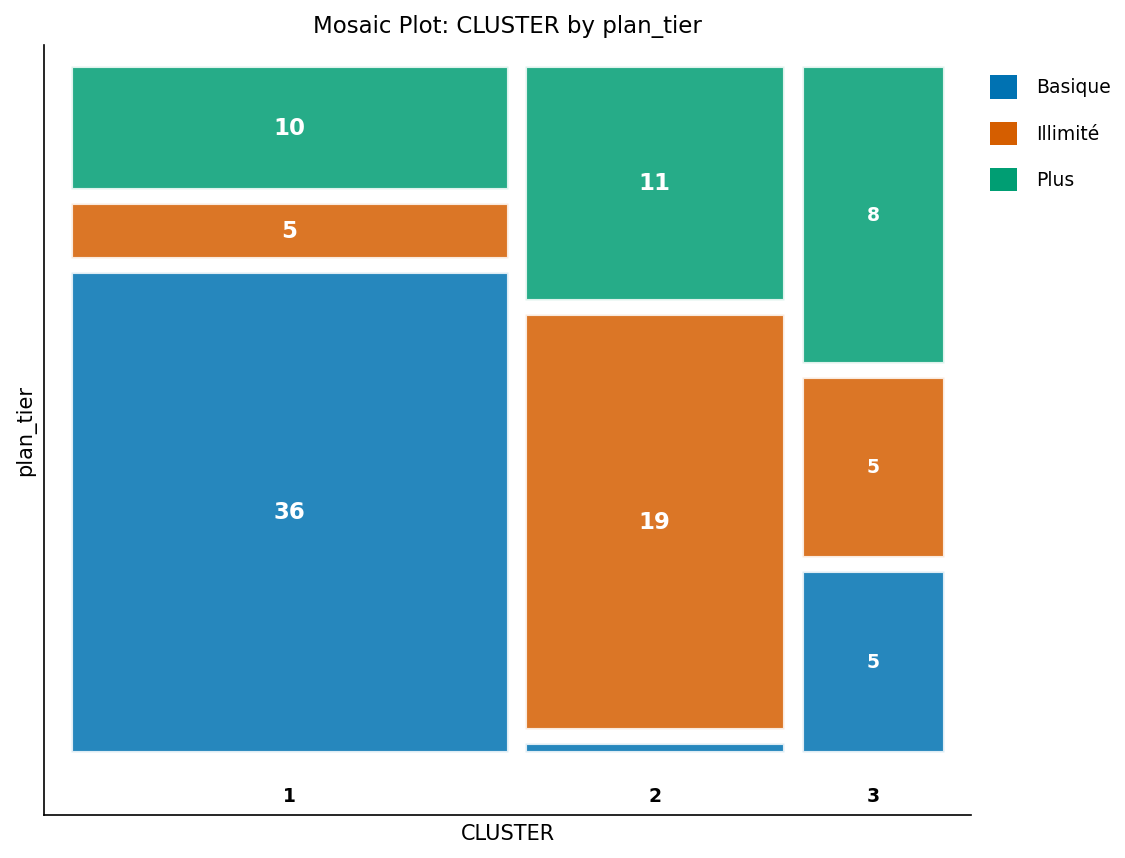

In [5]:
PROCÉDURE TRIER DONNÉES=scored out=scored_keys(GARDER=cust_id GRAPPE);
    PAR cust_id;
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=subscribers out=subs_sorted;
    PAR cust_id;
EXÉCUTER;

DONNÉES profile;
    FUSIONNER subs_sorted(DANS=a) scored_keys(DANS=b);
    PAR cust_id;
    SI a AND b;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=profile mean std MIN MAX maxdec=1;
    CLASSE GRAPPE;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ÉTIQUETTE tenure_months="Ancienneté (mois)" data_gb="Données (Go)" voice_min="Minutes voix"
          intl_min="Minutes internationales" support_calls="Appels support" monthly_charge="Facture mensuelle ($)";
    TITRE "Profils des segments : utilisation moyenne par segment (unités d'origine)";
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=profile;
    TABLES GRAPPE * plan_tier / nocol nopercent;
    ÉTIQUETTE plan_tier="Formule tarifaire";
    TITRE "Répartition des formules tarifaires au sein de chaque segment";
EXÉCUTER;


## Étape 6 - Réappliquer le modèle à l'instantané du mois prochain

Une segmentation n'est utile que si elle peut être réappliquée sans relancer tout le traitement. Les centroïdes enregistrés dans `SEG_SEEDS` à l'étape 4 constituent un modèle portable : les réinjecter via `SEED=SEG_SEEDS` avec `MAXITER=0` indique à FASTCLUS d'*affecter* chaque observation à son centroïde enregistré le plus proche sans déplacer les centroïdes - un pur score, pas un nouvel ajustement. Ici, nous re-scorons le même instantané standardisé pour confirmer que le modèle exporté reproduit les affectations d'origine ; en production, vous pointeriez plutôt `DATA=` vers l'instantané standardisé du mois prochain.


                             Répartition des formules tarifaires au sein de chaque segment                              


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


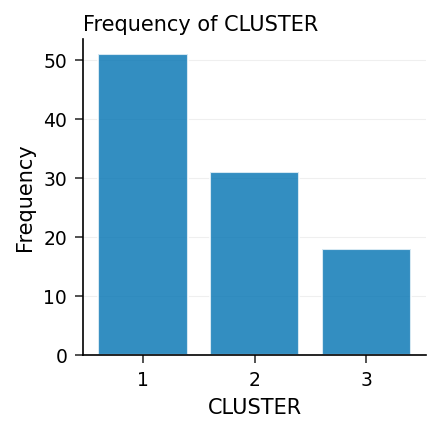

In [6]:
PROCÉDURE FASTCLUS DONNÉES=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    VAR tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    TITRE "Score d'un nouvel instantané à partir des centroïdes exportés";
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=rescored;
    TABLES GRAPPE / nocum;
    TITRE "Abonnés re-scorés via le modèle exporté";
EXÉCUTER;


## Interprétation des résultats

FASTCLUS a retrouvé les trois segments comportementaux intégrés dans les données, et les tables de profilage les traduisent en plan d'action de rétention. Lisez les numéros de segments dans la table *Profils des segments* ci-dessus - les étiquettes de segment sont arbitraires, donc identifiez chaque persona par sa signature d'utilisation :

- **Utilisateurs économes/valeur** - peu de données, factures modestes, ancienneté plus longue, très peu d'appels au support, majoritairement en *Basique*. Ces clients sont stables et sensibles au prix ; la bonne approche est de *protéger la marge*, pas de brader. Une recommandation de forfait bien dimensionné évite le choc de facturation sans cadeaux.
- **Gros consommateurs de données en streaming** - beaucoup de données, minutes vocales et internationales élevées, factures premium, majoritairement en *Illimité*. Ils sont fidèles et à forte valeur : l'approche est la *montée en gamme et le renouvellement d'appareils*, ainsi qu'une communication proactive sur la qualité du réseau afin qu'une promotion concurrente ne puisse pas les faire partir.
- **Forte sollicitation/à risque** - ancienneté courte, volume d'appels au support élevé, dépense intermédiaire. Les contacts fréquents avec le support et la faible ancienneté sont des signes précurseurs classiques de résiliation. C'est le segment qui mérite une *offre de rétention proactive* et un suivi de rattrapage de service.

Choix de procédure clés qui ont rendu cela fiable : **PROC STDIZE** a empêché les minutes vocales de grande magnitude de noyer le signal des appels au support ; le balayage pseudo-F a justifié le nombre de segments plutôt que de le deviner ; la pondération `FREQ` a fait compter les comptes familiaux multi-lignes proportionnellement à leur poids ; et l'aller-retour `OUTSEED=`/`SEED=` a exporté les centroïdes afin que l'équipe marketing puisse re-segmenter chaque instantané mensuel avec un simple appel FASTCLUS `MAXITER=0` - sans nouveau regroupement.
